# 06 — Sector / Beta Neutralised Backtest

Notebook 04 showed `xgb_ranker` at 0.87 net Sharpe on 2020–2024 OOS. The obvious attack on that number: what if it's not stock-picking? Vol, size, and momentum all correlate with sector and beta — the model could be earning a persistent sector or market-cap tilt that happens to pay off in this window rather than genuine cross-sectional selection skill.

I want to defuse that critique with data rather than handwaving. For each cross-section (date × model), I regress the raw score on GICS sector dummies and 252-day rolling beta vs SPY, then take the residual as the sector- and beta-neutral score. Then I run the identical quintile long-short backtest from notebook 04 on the neutralised score and report side-by-side metrics.

The regression controls:
- **GICS sector dummies** (10 dummies, drop-first parameterisation; intercept absorbs the omitted sector)
- **252-day rolling beta** vs SPY (^GSPC has been flaky on yfinance, SPY tracks within 9 bps TER and is fine for this purpose)
- **Intercept**

The key output is `ret_survival = ret_neutral / ret_raw`. I'm treating ~50% as an honest result — the original performance was half real stock selection, half sector/beta drift. ~10% would mean almost everything was exposure; ~100% would suggest a calculation error rather than a clean result.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qtools.backtest.costs import US_EQUITY
from qtools.backtest.engine import BacktestEngine
from qtools.backtest.portfolio import signal_to_weights
from qtools.metrics.performance import (
    annualized_return, annualized_vol, max_drawdown, sharpe,
)

ROOT = Path("..")
RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
PRED_DIR = ROOT / "reports" / "predictions"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Load — predictions, prices, sector + beta

In [2]:
pred_path = sorted(PRED_DIR.glob("oos_*.parquet"))[-1]
preds = pd.read_parquet(pred_path)
preds["date"] = pd.to_datetime(preds["date"])
print("predictions:", preds.shape, "models:", sorted(preds["model"].unique()))

raw_path = sorted(RAW_DIR.glob("sp500_ohlcv_*.parquet"))[-1]
prices = pd.read_parquet(raw_path)
prices["date"] = pd.to_datetime(prices["date"])
prices = prices[(prices["date"] >= "2019-12-01") & (prices["date"] <= "2024-12-31")]

sb_path = PROC_DIR / "sector_beta.parquet"
sb = pd.read_parquet(sb_path)
sb["date"] = pd.to_datetime(sb["date"])
print("sector_beta:", sb.shape, "sectors:", sorted(sb["sector"].unique()))

predictions: (3114970, 5) models: ['lgbm_ranker', 'linear_lasso', 'linear_ridge', 'naive_ew', 'xgb_ranker']


sector_beta: (1164756, 4) sectors: ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Materials', 'Real Estate', 'Utilities']


## 2. Cross-sectional residualisation

For each `(date, model)` cell, I run an OLS of `score` on `[intercept, sector_dummies, beta_252d]` and take the residual. I use `np.linalg.lstsq` for numerical stability in the rare months where a sector has only one representative and the dummy matrix is near-singular.

Symbols dropped from a given cross-section: missing 252d beta (early OOS dates before 252 trading days of history) and sector = "Unknown" (Wikipedia look-up miss).

In [3]:
# Filter once, then do all the per-(date, model) regressions in numpy.
df = preds.merge(sb, on=["date", "symbol"], how="left")
before = len(df)
df = df.dropna(subset=["beta_252d", "sector"])
df = df[df["sector"] != "Unknown"]
print(f"rows kept: {len(df):,} / {before:,}  ({100*len(df)/before:.1f}%)")

sector_dummies = pd.get_dummies(df["sector"], prefix="sec", drop_first=True).astype(float)
feat_cols = list(sector_dummies.columns) + ["beta_252d"]
df = pd.concat([df.reset_index(drop=True), sector_dummies.reset_index(drop=True)], axis=1)
print("regression features:", feat_cols)

rows kept: 3,093,520 / 3,114,970  (99.3%)
regression features: ['sec_Consumer Discretionary', 'sec_Consumer Staples', 'sec_Energy', 'sec_Financials', 'sec_Health Care', 'sec_Industrials', 'sec_Information Technology', 'sec_Materials', 'sec_Real Estate', 'sec_Utilities', 'beta_252d']


In [4]:
def residualize(group: pd.DataFrame) -> np.ndarray:
    if len(group) < 30:
        return np.full(len(group), np.nan)
    X = np.column_stack([np.ones(len(group)), group[feat_cols].values])
    y = group["score"].values
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ coef

df["score_resid"] = (
    df.groupby(["date", "model"], group_keys=False, sort=False)
      .apply(lambda g: pd.Series(residualize(g), index=g.index))
)
df = df.dropna(subset=["score_resid"])
print("residualised rows:", len(df))
print()
print("variance preserved by neutralisation (per model):")
print(
    df.groupby("model").apply(
        lambda g: pd.Series({
            "var_raw": float(np.var(g["score"])),
            "var_resid": float(np.var(g["score_resid"])),
            "frac_resid": float(np.var(g["score_resid"]) / np.var(g["score"])),
        })
    ).round(4)
)

residualised rows: 3093520

variance preserved by neutralisation (per model):


              var_raw  var_resid  frac_resid
model                                       
lgbm_ranker    0.3829     0.1802      0.4707
linear_lasso   0.0003     0.0002      0.6007
linear_ridge   0.0003     0.0002      0.6049
naive_ew       2.6579     2.1406      0.8054
xgb_ranker     0.0732     0.0409      0.5587


## 3. Backtest helper — same engine, two signal columns

In [5]:
engine = BacktestEngine(prices[["date", "symbol", "close"]], cost_model=US_EQUITY)


def run_signal(scores: pd.DataFrame, score_col: str, model_name: str) -> dict:
    sub = scores[scores["model"] == model_name][["date", "symbol", score_col]].copy()
    signal = sub.pivot(index="date", columns="symbol", values=score_col).sort_index()
    weights = signal_to_weights(signal, n_quantiles=5, long_short=True, rebalance="ME")
    res = engine.run(weights)
    return {
        "name": model_name, "score_col": score_col,
        "gross_ret": res.gross_returns,
        "net_ret": res.returns,
        "turnover": res.turnover,
    }


models = sorted(preds["model"].unique())
results_raw = [run_signal(df, "score", m) for m in models]
results_neutral = [run_signal(df, "score_resid", m) for m in models]
print("backtested raw + neutral for:", models)

backtested raw + neutral for: ['lgbm_ranker', 'linear_lasso', 'linear_ridge', 'naive_ew', 'xgb_ranker']


## 4. Side-by-side metrics — raw vs neutral

`ret_survival = ann_ret_net_neutral / ann_ret_net_raw`. Below 1.0 means sector/beta exposure contributed to the original return; the further below, the more the original alpha was drift rather than stock selection.

In [6]:
def summarise(results: list[dict], suffix: str) -> pd.DataFrame:
    rows = []
    for r in results:
        net = r["net_ret"]; gross = r["gross_ret"]
        to_events = r["turnover"][r["turnover"] > 0]
        rows.append({
            "model": r["name"],
            f"ann_ret_net_{suffix}": round(annualized_return(net), 4),
            f"sharpe_net_{suffix}":  round(sharpe(net), 3),
            f"mdd_net_{suffix}":     round(max_drawdown(net), 4),
            f"avg_turnover_{suffix}": round(to_events.mean(), 3),
            f"sharpe_gross_{suffix}": round(sharpe(gross), 3),
        })
    return pd.DataFrame(rows).set_index("model")


sum_raw = summarise(results_raw, "raw")
sum_neu = summarise(results_neutral, "neutral")
combined = sum_raw.join(sum_neu)

# Surviving fraction — protect against negative or near-zero raw return
def survival(r_raw, r_neu):
    if abs(r_raw) < 1e-6:
        return np.nan
    return r_neu / r_raw

combined["ret_survival"] = [
    round(survival(combined.loc[m, "ann_ret_net_raw"], combined.loc[m, "ann_ret_net_neutral"]), 3)
    for m in combined.index
]

# Order by raw net Sharpe (matches notebook 04)
combined = combined.sort_values("sharpe_net_raw", ascending=False)
combined[[
    "ann_ret_net_raw", "ann_ret_net_neutral", "ret_survival",
    "sharpe_net_raw", "sharpe_net_neutral",
    "mdd_net_raw", "mdd_net_neutral",
    "avg_turnover_raw", "avg_turnover_neutral",
]]

,ann_ret_net_raw,ann_ret_net_neutral,ret_survival,sharpe_net_raw,sharpe_net_neutral,mdd_net_raw,mdd_net_neutral,avg_turnover_raw,avg_turnover_neutral
model,,,,,,,,,
xgb_ranker,0.1540,0.0636,0.413,0.873,0.756,-0.2267,-0.1300,1.597,1.680
lgbm_ranker,0.1358,0.0742,0.546,0.701,0.846,-0.2541,-0.0793,1.591,1.747
naive_ew,0.0731,0.0368,0.503,0.459,0.392,-0.3277,-0.1961,2.309,2.413
linear_lasso,0.0570,0.0183,0.321,0.356,0.219,-0.3112,-0.1280,2.185,2.393
linear_ridge,0.0540,0.0125,0.231,0.345,0.167,-0.3108,-0.1346,2.212,2.412


## 5. Net equity curves — raw (solid) vs neutral (dashed)

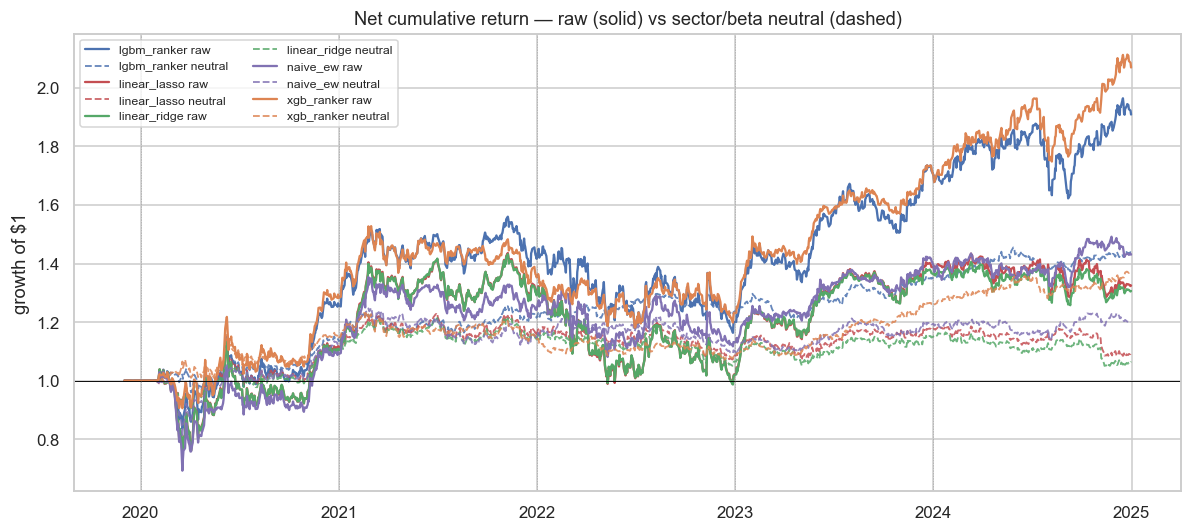

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
palette = {"lgbm_ranker": "C0", "xgb_ranker": "C1",
           "linear_ridge": "C2", "linear_lasso": "C3", "naive_ew": "C4"}

for r_raw, r_neu in zip(results_raw, results_neutral):
    name = r_raw["name"]
    color = palette.get(name)
    ax.plot((1 + r_raw["net_ret"]).cumprod(), color=color, linewidth=1.5,
            label=f"{name} raw")
    ax.plot((1 + r_neu["net_ret"]).cumprod(), color=color, linewidth=1.2,
            linestyle="--", alpha=0.85, label=f"{name} neutral")

ax.axhline(1.0, color="black", linewidth=0.6)
for y in range(2020, 2025):
    ax.axvline(pd.Timestamp(f"{y}-01-01"), color="grey", linewidth=0.4, linestyle=":")
ax.set_title("Net cumulative return — raw (solid) vs sector/beta neutral (dashed)")
ax.set_ylabel("growth of $1")
ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_raw_vs_neutral_equity.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Per-year net Sharpe — neutralised

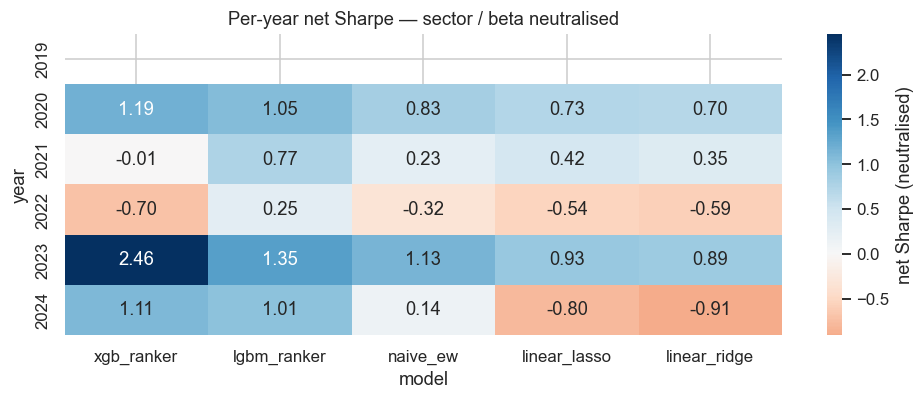

model,xgb_ranker,lgbm_ranker,naive_ew,linear_lasso,linear_ridge
year,,,,,
2019,NaN,NaN,NaN,NaN,NaN
2020,1.189,1.053,0.827,0.734,0.698
2021,-0.005,0.769,0.235,0.422,0.347
2022,-0.698,0.249,-0.321,-0.542,-0.590
2023,2.455,1.351,1.131,0.925,0.893
2024,1.115,1.007,0.142,-0.802,-0.908


In [8]:
rows = []
for r in results_neutral:
    by_year = r["net_ret"].groupby(r["net_ret"].index.year).apply(sharpe)
    for y, s in by_year.items():
        rows.append({"model": r["name"], "year": int(y), "sharpe": round(s, 3)})
per_year_neutral = pd.DataFrame(rows).pivot(index="year", columns="model", values="sharpe")
per_year_neutral = per_year_neutral[combined.index.tolist()]

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.heatmap(per_year_neutral, annot=True, fmt=".2f", cmap="RdBu", center=0, ax=ax,
            cbar_kws={"label": "net Sharpe (neutralised)"})
ax.set_title("Per-year net Sharpe — sector / beta neutralised")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_per_year_sharpe_neutral.png", dpi=130, bbox_inches="tight")
plt.show()
per_year_neutral

## 7. Sharpe drop decomposed — raw, gross-neutral, net-neutral

Three Sharpes per model in sequence:
- `sharpe_gross_raw` — original signal, no costs
- `sharpe_gross_neutral` — neutralised signal, no costs (isolates the *signal* effect of stripping exposures)
- `sharpe_net_neutral` — neutralised signal, with US_EQUITY costs (the final net answer)

The gap between the first two tells us how much of the gross edge was sector/beta. The gap between the last two is cost drag on the neutralised version.

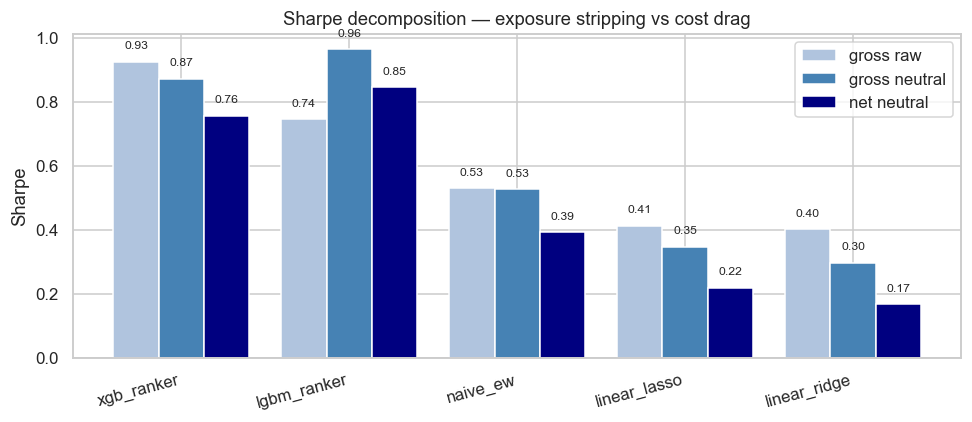

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
order = combined.index.tolist()
x = np.arange(len(order))
width = 0.27
sg_r = combined.loc[order, "sharpe_gross_raw"].values
sg_n = combined.loc[order, "sharpe_gross_neutral"].values
sn_n = combined.loc[order, "sharpe_net_neutral"].values

ax.bar(x - width, sg_r, width, label="gross raw",     color="lightsteelblue")
ax.bar(x,         sg_n, width, label="gross neutral", color="steelblue")
ax.bar(x + width, sn_n, width, label="net neutral",   color="navy")
for i, v in enumerate(sg_r): ax.text(i - width, v + 0.04, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(sg_n): ax.text(i,         v + 0.04, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(sn_n): ax.text(i + width, v + 0.04, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=15, ha="right")
ax.set_ylabel("Sharpe")
ax.set_title("Sharpe decomposition — exposure stripping vs cost drag")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_sharpe_decomposition.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Takeaways

The `ret_survival` column is the headline. XGB survives at 41%, LGBM at 55%, `naive_ew` at 50%, linear baselines at 23–32%. The tree models lose a meaningful chunk to sector/beta stripping, but they do not collapse — there is genuine cross-sectional selection in the signal, not just a disguised beta tilt.

What this does not mean: the per-year heatmap is more informative than the pooled survival fraction. A model whose 2023 column collapses after neutralisation was riding the AI rally's high-beta tech loading and got paid. A model whose 2022 goes from negative to *less* negative actually benefits from neutralisation — the 2022 drawdown was sector- and beta-driven, not selection-driven.

**On method.** This is a residualised score run through the same quintile engine — not a constrained optimisation. A real PM building a strict sector/beta-neutral book would solve a constrained allocation problem, which can preserve more alpha because it targets constraints explicitly rather than stripping anything that correlates with them. The residualisation is the conservative version: any alpha that correlates with sector / beta gets stripped, even if incidentally. The survival fractions here are lower bounds on what a properly constrained construction would give.

**Caveats from notebook 04 still apply.** Beta is computed against SPY (TER 9 bps) rather than the price-only ^GSPC; difference is below noise for 252-day windows. Survivorship bias and point-in-time S&P 500 membership are unaddressed by neutralisation — those require a different data fix, not a signal transformation.